This code loops through sessions containing Patch Foraging and FIP towards assembling a concatenated cross-session data table.

In [1]:
##Imports + config

from aind_vr_foraging_analysis.utils.parsing import parse, data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
import pytz
from datetime import datetime
sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
from pathlib import Path
import os, glob, csv, json, re
import numpy as np
import pandas as pd

import PreprocessingFunctions_v2 as pf

from aind_vr_foraging_analysis.utils.parsing import parse, data_access

# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

# -------------------------
# FIP preprocessing params
# -------------------------
nFrame2cut   = 100
sampling_rate = 20     # Hz per channel
kernelSize   = 1
degree       = 4
b_percentile = 0.70

# Keep file size reasonable
Roi2Vis = [0, 1]       # or None for all ROIs

# Align/export settings
ALIGN_LABELS = ["OdorSite","InterSite","InterPatch"]   
T_PRE  = 4.0
T_POST = 4.0

# Output
OUTDIR = Path(r"Z:\jason.lee\patch_foraging\Data\multisession_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)


In [2]:
##FIP loader

def load_fip_preprocess(FIP_Dir: Path,
                        nFrame2cut=100, sampling_rate=20,
                        kernelSize=1, degree=4, b_percentile=0.70):
    """
    Returns:
      time_seconds: (T,)
      Ctrl_dF_F, G_dF_F, R_dF_F: (T, n_rois)
    """
    FIP_Dir = Path(FIP_Dir)
    try:
        file1 = glob.glob(str(FIP_Dir / "FIP_DataIso_*"))[0]
    except Exception:
        file1 = glob.glob(str(FIP_Dir / "iso.csv"))[0]
        file2 = glob.glob(str(FIP_Dir / "green.csv"))[0]
        file3 = glob.glob(str(FIP_Dir / "red.csv"))[0]
    else:
        file2 = glob.glob(str(FIP_Dir / "green.csv"))[0]
        file3 = glob.glob(str(FIP_Dir / "red.csv"))[0]

    def _read_csv_float64(fp):
        with open(fp) as f:
            reader = csv.reader(f)
            datatemp = np.array([row for row in reader])
        return datatemp[1:, :].astype(np.float64)

    data1 = _read_csv_float64(file1)  # iso
    data2 = _read_csv_float64(file2)  # green
    data3 = _read_csv_float64(file3)  # red (or stim in some conventions)

    # truncate to common length
    L = np.amin([len(data1), len(data2), len(data3)])
    data1, data2, data3 = data1[:L], data2[:L], data3[:L]

    time_seconds = np.arange(L, dtype=float) / float(sampling_rate)

    PMts = data2[:,0].astype(float)

    # Allocate: use only ROI columns (you store in first columns too, but you fill [:, ii])
    # uses shape (T, data1.shape[1]) but fills only first n_rois.
    n_cols = data1.shape[1]
    Ctrl_dF_F = np.zeros((L, n_cols), dtype=float)
    G_dF_F    = np.zeros((L, n_cols), dtype=float)
    R_dF_F    = np.zeros((L, n_cols), dtype=float)

    # skip first 4 columns; fibers are cols 4-7 (0-index: 4..)
    n_rois = data2.shape[1] - 4
    for ii in range(n_rois):
        Ctrl_dF_F[:, ii] = pf.tc_preprocess(data1[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
        G_dF_F[:, ii]    = pf.tc_preprocess(data2[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
        R_dF_F[:, ii]    = pf.tc_preprocess(data3[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)

    # Trim to actual ROI count for cleanliness
    Ctrl_dF_F = Ctrl_dF_F[:, :n_rois]
    G_dF_F    = G_dF_F[:, :n_rois]
    R_dF_F    = R_dF_F[:, :n_rois]

    return PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F

In [28]:
#Alignment + Long table builder

def _extract_window_fixed(y_1d, center_idx, pre_frames, post_frames):
    L = pre_frames + post_frames + 1
    out = np.full(L, np.nan, dtype=float)
    start = center_idx - pre_frames
    end   = center_idx + post_frames + 1

    src_start = max(start, 0)
    src_end   = min(end, len(y_1d))
    dst_start = src_start - start
    dst_end   = dst_start + (src_end - src_start)

    out[dst_start:dst_end] = y_1d[src_start:src_end].astype(float)
    return out

def build_session_aligned_long(all_epochs: pd.DataFrame,
                               time_seconds: np.ndarray,
                               Ctrl_dF_F: np.ndarray,
                               G_dF_F: np.ndarray,
                               R_dF_F: np.ndarray,
                               mouse: str,
                               session_id: str,
                               align_labels=("OdorSite",),
                               align_time_col="epoch_time",
                               extra_filter=None,          # function(df)->mask or None
                               t_pre=2.0,
                               t_post=5.0,
                               rois=None,
                               sampling_rate=20,
                               baseline_window=(-2.0, 0.0),
                               add_value_bs=True,
                               add_value_z=True,
                               zscore_mode="baseline"
                               ):
    """
    Returns:
      epochs_df: all_epochs with ids + epoch_time column
      aligned_long: long table for selected align_labels
    """
    epochs_df = all_epochs.copy()
    epochs_df = all_epochs.reset_index()
    # Whatever the first column is after reset_index() is the old index
    idx_col = epochs_df.columns[0]
    epochs_df = epochs_df.rename(columns={idx_col: "epoch_time"})

    epochs_df['mouse'] = str(mouse)
    epochs_df['session_id'] = str(session_id)
    epochs_df['epoch_id'] = (
        epochs_df['mouse'].astype(str) + "_" +
        epochs_df['session_id'].astype(str) + "_" +
        epochs_df.index.astype(str)
    )

    pre_frames  = int(round(t_pre * sampling_rate))
    post_frames = int(round(t_post * sampling_rate))
    t_rel = (np.arange(-pre_frames, post_frames + 1) / sampling_rate).astype(float)

    b0, b1 = baseline_window
    base_mask = (t_rel >= b0) & (t_rel < b1)


    n_rois = Ctrl_dF_F.shape[1]
    if rois is None:
        rois = list(range(n_rois))

    chan_map = {'Ctrl': Ctrl_dF_F, 'G': G_dF_F, 'R': R_dF_F}

    all_rows = []
    for align_label in align_labels:
        mask = epochs_df['label'].eq(align_label)
        if extra_filter is not None:
            mask &= extra_filter(epochs_df)

        align_df = epochs_df.loc[mask].copy()

        # if aligning by reward_onset_time (or any other col), drop rows where it's missing
        align_df = align_df.dropna(subset=[align_time_col])

        if align_df.empty:
            continue


        # QC: epoch times inside range?
        tmin, tmax = float(np.nanmin(align_df['epoch_time'])), float(np.nanmax(align_df['epoch_time']))
        if tmin < -1e-3 or tmax > float(time_seconds[-1]) + 1e-3:
            # still proceed, but many windows may pad NaNs
            pass

        # time -> nearest frame (uniform fs)
        times = align_df[align_time_col].astype(float).to_numpy()
        center_idx = np.searchsorted(PMts, times).astype(int)
        center_idx = np.clip(center_idx, 0, len(PMts)-1)



        # build long rows
        for k, (ei, cidx) in enumerate(zip(align_df['epoch_id'].values, center_idx)):
            meta = align_df.iloc[k].to_dict()
            for roi in rois:
                for ch_name, arr in chan_map.items():
                    y_win = _extract_window_fixed(arr[:, roi], cidx, pre_frames, post_frames)

                    # baseline mean/std (per-epoch, per channel×roi)
                    if zscore_mode == "baseline":
                        y_base = y_win[base_mask]
                    else:  # "window"
                        y_base = y_win

                    mu = np.nanmean(y_base)
                    sd = np.nanstd(y_base)
                    if not np.isfinite(sd) or sd == 0:
                        sd = np.nan

                    row = {
                        'mouse': meta['mouse'],
                        'session_id': meta['session_id'],
                        'epoch_id': ei,
                        'align_label': align_label,
                        't_rel': t_rel,
                        'roi': int(roi),
                        'channel': ch_name,
                        'value': y_win,
                        'label': meta.get('label', None),
                        'patch_label': meta.get('patch_label', None),
                        'odor_label': meta.get('odor_label', None),
                        'is_reward': meta.get('is_reward', None),
                        'is_choice': meta.get('is_choice', None),
                    }

                    if add_value_bs:
                        row['value_bs'] = y_win - mu

                    if add_value_z:
                        row['value_z'] = (y_win - mu) / sd

                    all_rows.append(pd.DataFrame(row))


    aligned_long = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    return epochs_df, aligned_long


In [4]:
from os import PathLike

class MetricsVrForaging():
    def __init__(self, session_path: PathLike):
        self.session_path = session_path
        self.active_site, self.stream_data, self.data = data_access.load_session(
        session_path
        )
        
        
        self.reward_sites = self.active_site.loc[self.active_site['label'] == 'OdorSite']

        utc = pytz.UTC
        local_tz = pytz.timezone("America/Los_Angeles")

        utc_str = self.data['config'].streams.session_input.data['date']
        utc_dt = datetime.fromisoformat(utc_str)        # full timestamp
        local_dt = utc_dt.replace(tzinfo=utc).astimezone(local_tz)
        self.session = str(local_dt.date())  
        self.mouse = int(self.data['config'].streams.session_input.data['subject'])
        self.stage = self.data['config'].streams.tasklogic_input.data['stage_name']
        self.rig_name = self.data['config'].streams.rig_input.data['rig_name']
        self.experimenter = self.data['config'].streams.session_input.data['experimenter'][0]
        self.updaters = self.data['config'].streams.tasklogic_input.data['task_parameters']['updaters']
        
        if self.stage == 'thermistor screening':
            return
        
        self.df = self.retrieve_metrics()

    def retrieve_metrics(self) -> pd.DataFrame:
        reward_sites = self.reward_sites
        active_site = self.active_site
        data = self.data

        df = pd.DataFrame()
        # Summary of different relevants aspects -------------------------------------------------

        unrewarded_stops = reward_sites.loc[reward_sites.is_reward==0]['reward_amount'].count()
        rewarded_stops = reward_sites.loc[reward_sites.is_reward==1]['reward_amount'].count()
        water_collected = reward_sites.loc[(reward_sites['is_reward']==1)]['reward_amount'].sum()
        total_stops = reward_sites.loc[(reward_sites['is_choice']==True)]['reward_amount'].count()
            
        df.at[0,'odor_sites_travelled'] = int(len(reward_sites))
        df.at[0,'distance_m'] = data['operation_control'].streams.CurrentPosition.data.max()[0]/100
        df.at[0,'water_collected_ul'] = water_collected
        df.at[0,'rewarded_stops'] = int(rewarded_stops)
        df.at[0,'total_stops'] = int(total_stops)
        df.at[0,'session_duration_min'] = (reward_sites.index[-1] - reward_sites.index[0])/60
        df.at[0, 'total_patches_visited'] = reward_sites.loc[reward_sites['site_number'] >= 1].patch_number.nunique()
        return df

    def retrieve_updater_values(self):
        # Initialize a pointer for the data values
        data_pointer = 0
        
        reward_sites = self.reward_sites
        data = self.data
        df = self.df
        
        # Helper function to safely extract stream data
        def get_stream_data(data, key):
            try:
                stream = data['updater_events'].streams[key].data['data']
                stream.reset_index(drop=True, inplace=True)
                return stream
            except (KeyError, AttributeError):
                return None

        # Load updater data safely
        stop_duration = get_stream_data(data, 'UpdaterStopDurationOffset')
        delay = get_stream_data(data, 'UpdaterRewardDelayOffset')
        velocity_threshold = get_stream_data(data, 'UpdaterStopVelocityThreshold')

        # Create new columns in reward_sites with default values
        reward_sites['delay_s'] = np.nan
        reward_sites['velocity_threshold_cms'] = np.nan
        reward_sites['stop_duration_s'] = np.nan

        data_pointer = 0
        try:
            for index, row in reward_sites.iterrows():
                if row['is_reward'] == 1:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
                    data_pointer += 1
                else:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
        except IndexError:
            if delay is not None:
                reward_sites.at[index, 'delay_s'] = delay.max()
            if velocity_threshold is not None:
                reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold.max()
            if stop_duration is not None:
                reward_sites.at[index, 'stop_duration_s'] = stop_duration.max()

        # Summary of the training metrics
        reward_sites['odor_sites'] = np.arange(1, len(reward_sites) + 1)

        # Safely update df only if values exist
        if delay is not None:
            df.at[0, 'start_delay'] = reward_sites['delay_s'].min()
            df.at[0, 'end_delay'] = reward_sites['delay_s'].max()
            df.at[0, 'sites_to_max_delay'] = reward_sites[reward_sites['delay_s'] == reward_sites['delay_s'].max()].iloc[0]['odor_sites']

        if stop_duration is not None:
            df.at[0, 'start_stop_duration'] = reward_sites['stop_duration_s'].min()
            df.at[0, 'end_stop_duration'] = reward_sites['stop_duration_s'].max()
            df.at[0, 'sites_to_max_stop_duration'] = reward_sites[reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()].iloc[0]['odor_sites']
            df.at[0, 'rewarded_sites_in_max_stop'] = int(reward_sites[(reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()) & (reward_sites.is_choice == 1)]['odor_sites'].nunique())

        if velocity_threshold is not None:
            df.at[0, 'start_velocity_threshold'] = reward_sites['velocity_threshold_cms'].min()
            df.at[0, 'end_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'target_max_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'sites_to_min_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].min()].iloc[0]['odor_sites']
            df.at[0, 'sites_to_max_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].max()].iloc[0]['odor_sites']        
        
        self.reward_sites = reward_sites
        self.df = df

    def get_metrics(self):
        return self.df

    def get_reward_sites(self):
        return self.reward_sites
    
    def get_mouse_and_session(self):
        return self.mouse, self.session
    

In [5]:
mouse_list = ["788731"]
date_string = "2025-12-09"
end_date_string = "2025-12-25"

In [74]:
import re
from pathlib import Path
import pandas as pd

sessions_rows = []

for mouse in mouse_list:
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        end_date_string=end_date_string,
        when='between'
    )

    for session_path in session_paths:
        session_path = Path(session_path)
        parsed = MetricsVrForaging(session_path)

        sessions_rows.append({
            "mouse": mouse,
            "session_path": str(session_path),
            "session": parsed.session,              # e.g. datetime / string
            "stage": parsed.stage,
        })

sessions_manifest = pd.DataFrame(sessions_rows)

print("sessions:", len(sessions_manifest))
sessions_manifest.head()


Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
sessions: 7


,mouse,session_path,session,stage
0,788731,Y:\vr-foraging\data\788731\788731_2025-12-09T1...,2025-12-09,graduation
1,788731,Y:\vr-foraging\data\788731\788731_2025-12-10T2...,2025-12-10,graduation
2,788731,Y:\vr-foraging\data\788731\788731_2025-12-11T1...,2025-12-11,graduation
3,788731,Y:\vr-foraging\data\788731\788731_2025-12-12T2...,2025-12-12,graduation
4,788731,Y:\vr-foraging\data\788731\788731_2025-12-15T2...,2025-12-15,graduation


In [108]:
epoch_tables = []
aligned_tables = []
failed = []

for row in sessions_manifest.itertuples(index=False):
    session_path = Path(row.session_path)

    try:
        # 1) Load behavior epochs
        all_epochs, stream_data, data = data_access.load_session(session_path)
        all_epochs = all_epochs.copy()
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)

        # 2) Determine FIP_Dir
        fib_dir = session_path / "fib"
        FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
        FIP_Dir = str(FIP_Dir)

        # 3) Load & preprocess FIP
        PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F = load_fip_preprocess(
            FIP_Dir,
            nFrame2cut=nFrame2cut,
            sampling_rate=sampling_rate,
            kernelSize=kernelSize,
            degree=degree,
            b_percentile=b_percentile
        )

        # 4) Build aligned long table
        epochs_df, aligned_long = build_session_aligned_long(
            all_epochs=all_epochs,
            time_seconds=time_seconds,
            Ctrl_dF_F=Ctrl_dF_F,
            G_dF_F=G_dF_F,
            R_dF_F=R_dF_F,
            mouse=row.mouse,
            session_id=str(row.session),      # or row.session_id 
            align_labels=ALIGN_LABELS,
            extra_filter=None,                # or odor_60/odor_90 filter
            t_pre=T_PRE,
            t_post=T_POST,
            rois=Roi2Vis,
            sampling_rate=sampling_rate
        )

        # 5) Attach manifest metadata (so you can groupby stage/rig/trainer later)
        meta_cols = {
            "session": row.session,
            "stage": row.stage,
            "session_path": str(session_path),
        }
        for k, v in meta_cols.items():
            epochs_df[k] = v
            if not aligned_long.empty:
                aligned_long[k] = v

        # # Optional QC: warn if mostly NaNs (clock mismatch / edge effects)
        # if not aligned_long.empty:
        #     frac_valid = float(np.mean(~np.isnan(aligned_long["value"].to_numpy())))
        #     if frac_valid < 0.5:
        #         print(f"WARNING low valid fraction {frac_valid:.2f} for {row.mouse} {row.session}")

        epoch_tables.append(epochs_df)
        aligned_tables.append(aligned_long)

        print(f"OK: mouse={row.mouse} session={row.session} epochs={len(epochs_df)} aligned_rows={len(aligned_long)}")

    except Exception as e:
        failed.append({
            "mouse": row.mouse,
            "session": row.session,
            "session_path": str(session_path),
            "error": repr(e),
        })
        print(f"FAIL: mouse={row.mouse} session={row.session}  {repr(e)}")

EPOCHS_ALL  = pd.concat(epoch_tables, ignore_index=True) if epoch_tables else pd.DataFrame()
ALIGNED_ALL = pd.concat(aligned_tables, ignore_index=True) if aligned_tables else pd.DataFrame()
FAILED = pd.DataFrame(failed)

print("EPOCHS_ALL:", EPOCHS_ALL.shape)
print("ALIGNED_ALL:", ALIGNED_ALL.shape)
print("FAILED:", FAILED.shape)


Reward functions from software events
OK: mouse=788731 session=2025-12-09 epochs=959 aligned_rows=926394
Reward functions from software events
OK: mouse=788731 session=2025-12-10 epochs=975 aligned_rows=941850
Reward functions from software events
OK: mouse=788731 session=2025-12-11 epochs=697 aligned_rows=673302
Reward functions from software events
OK: mouse=788731 session=2025-12-12 epochs=919 aligned_rows=887754
Reward functions from software events
OK: mouse=788731 session=2025-12-15 epochs=1013 aligned_rows=978558
Reward functions from software events
OK: mouse=788731 session=2025-12-17 epochs=893 aligned_rows=862638
Reward functions from software events
OK: mouse=788731 session=2025-12-19 epochs=885 aligned_rows=854910
EPOCHS_ALL: (6341, 39)
ALIGNED_ALL: (6125406, 16)
FAILED: (0, 0)


In [47]:
# Save manifest and tables
EPOCHS_ALL.to_csv(OUTDIR / "epochs_all.csv.", index=False)
ALIGNED_ALL.to_csv(OUTDIR / "aligned_all.csv", index=False)
sessions_manifest.to_csv(OUTDIR / "sessions_manifest.csv", index=False)

print("Saved CSVs to:", OUTDIR)

Saved CSVs to: Z:\jason.lee\patch_foraging\Data\multisession_tables


In [110]:
EPOCHS_ALL.to_csv(OUTDIR / "epochs_all.csv.gz", index=False, compression="gzip")
ALIGNED_ALL.to_csv(OUTDIR / "aligned_all.csv.gz", index=False, compression="gzip")
sessions_manifest.to_csv(OUTDIR / "sessions_manifest.csv.gz", index=False, compression="gzip")


In [30]:
#Read csv
aligned = pd.read_csv(OUTDIR / "aligned_all.csv.gz")
epochs  = pd.read_csv(OUTDIR / "epochs_all.csv.gz")
sessions_manifest = pd.read_csv(OUTDIR / "sessions_manifest.csv.gz")


In [8]:
epochs.columns

Index(['epoch_time', 'label', 'start_position', 'length', 'friction',
       'patch_number', 'patch_label', 'odor_label', 'site_number', 'stop_time',
       'choice_cue_time', 'reward_onset_time', 'succesful_wait_time',
       'is_choice', 'is_reward', 'reward_amount', 'reward_probability',
       'reward_available', 'odor_sites', 'collected', 'depleted', 'last_visit',
       'last_site', 'cumulative_rewards', 'consecutive_rewards',
       'cumulative_failures', 'consecutive_failures',
       'after_choice_cumulative_rewards', 'duration_epoch', 'patch_onset',
       'time_since_entry', 'exit_epoch', 'skipped_count', 'mouse',
       'session_id', 'epoch_id', 'session', 'stage', 'session_path'],
      dtype='object')

In [ ]:
#Generate RewardOnset aligned table
epoch_tables = []
aligned_tables = []
failed = []

for row in sessions_manifest.itertuples(index=False):
    session_path = Path(row.session_path)

    try:
        # 1) Load behavior epochs
        all_epochs, stream_data, data = data_access.load_session(session_path)
        all_epochs = all_epochs.copy()
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)

        # 2) Determine FIP_Dir
        fib_dir = session_path / "fib"
        FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
        FIP_Dir = str(FIP_Dir)

        # 3) Load & preprocess FIP
        PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F = load_fip_preprocess(
            FIP_Dir,
            nFrame2cut=nFrame2cut,
            sampling_rate=sampling_rate,
            kernelSize=kernelSize,
            degree=degree,
            b_percentile=b_percentile
        )

        # 4) Build aligned long table
        epochs_df, aligned_long = build_session_aligned_long(
            all_epochs=all_epochs,
            time_seconds=time_seconds,
            Ctrl_dF_F=Ctrl_dF_F,
            G_dF_F=G_dF_F,
            R_dF_F=R_dF_F,
            mouse=row.mouse,
            session_id=str(row.session),      # or row.session_id 
            align_labels=("OdorSite",),
            extra_filter=None,                # or odor_60/odor_90 filter
            t_pre=T_PRE,
            t_post=T_POST,
            rois=Roi2Vis,
            sampling_rate=sampling_rate,
            baseline_window=(-2.0, 0.0),
            add_value_bs=True,
            add_value_z=True,
            zscore_mode="baseline",
            align_time_col="reward_onset_time"  # <-- THIS makes t_rel=0 = reward onset
        )

        # 5) Attach manifest metadata (so you can groupby stage/rig/trainer later)
        meta_cols = {
            "session": row.session,
            "stage": row.stage,
            "session_path": str(session_path),
        }
        for k, v in meta_cols.items():
            epochs_df[k] = v
            if not aligned_long.empty:
                aligned_long[k] = v

        # # Optional QC: warn if mostly NaNs (clock mismatch / edge effects)
        # if not aligned_long.empty:
        #     frac_valid = float(np.mean(~np.isnan(aligned_long["value"].to_numpy())))
        #     if frac_valid < 0.5:
        #         print(f"WARNING low valid fraction {frac_valid:.2f} for {row.mouse} {row.session}")

        epoch_tables.append(epochs_df)
        aligned_tables.append(aligned_long)

        print(f"OK: mouse={row.mouse} session={row.session} epochs={len(epochs_df)} aligned_rows={len(aligned_long)}")

    except Exception as e:
        failed.append({
            "mouse": row.mouse,
            "session": row.session,
            "session_path": str(session_path),
            "error": repr(e),
        })
        print(f"FAIL: mouse={row.mouse} session={row.session}  {repr(e)}")

EPOCHS_RWD  = pd.concat(epoch_tables, ignore_index=True) if epoch_tables else pd.DataFrame()
ALIGNED_RWD = pd.concat(aligned_tables, ignore_index=True) if aligned_tables else pd.DataFrame()
FAILED = pd.DataFrame(failed)

print("EPOCHS_ALL:", EPOCHS_RWD.shape)
print("ALIGNED_ALL:", ALIGNED_RWD.shape)
print("FAILED:", FAILED.shape)

Reward functions from software events
OK: mouse=788731 session=2025-12-09 epochs=959 aligned_rows=154560
Reward functions from software events
OK: mouse=788731 session=2025-12-10 epochs=975 aligned_rows=170016
Reward functions from software events
OK: mouse=788731 session=2025-12-11 epochs=697 aligned_rows=113022
Reward functions from software events
OK: mouse=788731 session=2025-12-12 epochs=919 aligned_rows=154560
Reward functions from software events
OK: mouse=788731 session=2025-12-15 epochs=1013 aligned_rows=176778
Reward functions from software events
OK: mouse=788731 session=2025-12-17 epochs=893 aligned_rows=170016
Reward functions from software events
OK: mouse=788731 session=2025-12-19 epochs=885 aligned_rows=175812


NameError: name 'EPOCHS_ALL' is not defined

In [32]:
EPOCHS_RWD.to_csv(OUTDIR / "epochs_rwd.csv.gz", index=False, compression="gzip")
ALIGNED_RWD.to_csv(OUTDIR / "aligned_rwd.csv.gz", index=False, compression="gzip")

In [33]:
#Read csv
aligned = pd.read_csv(OUTDIR / "aligned_rwd.csv.gz")
epochs  = pd.read_csv(OUTDIR / "epochs_rwd.csv.gz")

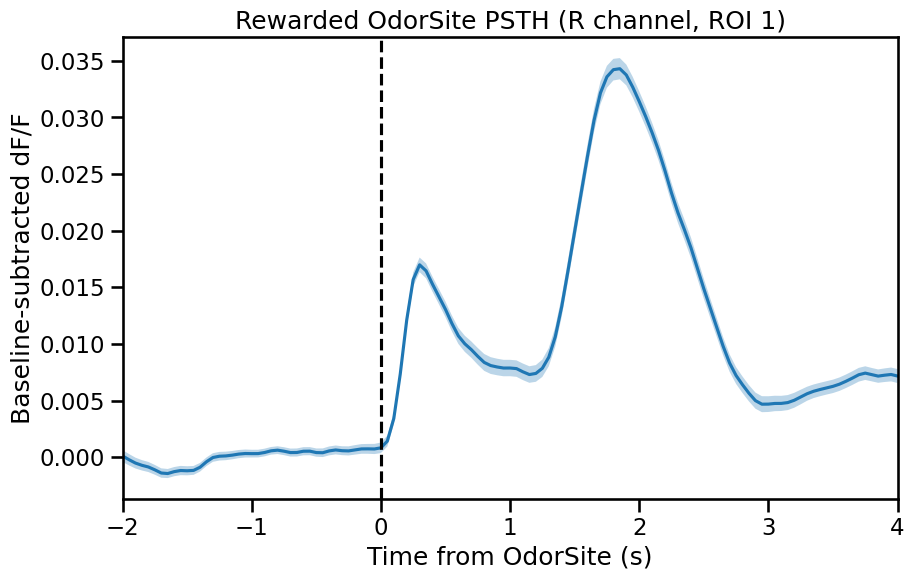

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
CHANNEL = "R"     # or "G" / "Ctrl"
ROI = 1
BASELINE_WIN = (-2.0, 0)   # seconds relative to OdorSite
XLIM = (-2.0, 4.0)

df = aligned.copy()

# Filter to rewarded OdorSite events for one ROI/channel
od = df[
    (df["align_label"] == "OdorSite") &
    (df["label"] == "OdorSite") &
    (df["channel"] == CHANNEL) &
    (df["roi"] == ROI) &
    (df["is_choice"].astype(float) == 1.0) &
    (df["is_reward"].astype(float) == 1.0)
].copy()

# Baseline per epoch_id (pre-event window)
b0, b1 = BASELINE_WIN
base = (od[(od["t_rel"] >= b0) & (od["t_rel"] <= b1)]
        .groupby("epoch_id")["value"]
        .mean()
        .rename("baseline"))

od = od.join(base, on="epoch_id")
od = od.dropna(subset=["baseline"])
od["value_bs"] = od["value"] - od["baseline"]

# Event-weighted mean ± SEM across all rewarded odorsites
psth = (od.groupby("t_rel")["value_bs"]
        .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
        .reset_index())

# Plot
plt.figure(figsize=(10,6))
plt.plot(psth["t_rel"], psth["mean"])
plt.fill_between(psth["t_rel"], psth["mean"]-psth["sem"], psth["mean"]+psth["sem"], alpha=0.3)
plt.axvline(0, color="k", linestyle="--")
plt.xlim(*XLIM)
plt.xlabel("Time from OdorSite (s)")
plt.ylabel("Baseline-subtracted dF/F")
plt.title(f"Rewarded OdorSite PSTH ({CHANNEL} channel, ROI {ROI})")
plt.show()


In [10]:
fs = 20.0
dt = 1.0/fs
tol = dt/2 + 1e-9   # tolerance for matching patch_onset to InterSite epoch_time

In [113]:
# Focus to R channel ROI 1
aligned_R1 = aligned[(aligned["channel"] == "R") & (aligned["roi"] == 1)].copy()

# Bring epoch_time, patch_onset, and metadata onto aligned rows
# (If aligned already has mouse/session, this merge is harmless.)
meta_cols = ["epoch_id", "mouse", "session", "label", "epoch_time", "patch_onset", "reward_onset_time"]
meta_cols = [c for c in meta_cols if c in epochs.columns]  # keep only present
aligned_R1 = aligned_R1.merge(epochs[meta_cols], on="epoch_id", how="left")

# Select patch-onset InterSite epochs: align_label == "InterSite" AND epoch_time ≈ patch_onset
inter_patch_onset = aligned_R1[
    (aligned_R1["align_label"] == "InterSite") &
    (aligned_R1["patch_onset"].notna()) &
    (aligned_R1["epoch_time"].notna()) &
    (np.abs(aligned_R1["epoch_time"].astype(float) - aligned_R1["patch_onset"].astype(float)) <= tol)
].copy()

# Baseline window [-2, 0)
baseline_win = inter_patch_onset[(inter_patch_onset["t_rel"] >= -2.0) & (inter_patch_onset["t_rel"] < 0.0)].copy()

# Define a patch key. Using mouse+session+patch_onset is usually sufficient.
# pick an ID column that exists
IDCOL = "session_path" if "session_path" in epochs.columns else "session_id" if "session_id" in epochs.columns else "session"

baseline_win["patch_key"] = (
    baseline_win[IDCOL].astype(str) + "|" +
    baseline_win["patch_onset"].astype(str)
)


baseline_per_patch = (
    baseline_win.groupby("patch_key")["value"]
    .mean()
    .rename("baseline_patch")
    .reset_index()
)


In [114]:
# OdorSite-aligned rows (we re-center these)
odor = aligned_R1[
    (aligned_R1["align_label"] == "OdorSite") &
    (aligned_R1["reward_onset_time"].notna()) &
    (aligned_R1["epoch_time"].notna()) &
    (aligned_R1["patch_onset"].notna())
].copy()

odor["reward_rel"] = odor["reward_onset_time"].astype(float) - odor["epoch_time"].astype(float)
odor["t_rel_reward"] = odor["t_rel"].astype(float) - odor["reward_rel"]

# Snap to 20 Hz grid (0.05 s) so groupby works cleanly
odor["t_rel_reward_bin"] = np.round(odor["t_rel_reward"] / dt) * dt

# Optional: choose the RewardOnset PSTH window you care about
odor = odor[(odor["t_rel_reward_bin"] >= -2.0) & (odor["t_rel_reward_bin"] <= 5.0)].copy()

# Attach patch_key and baseline
odor["patch_key"] = (
    odor[IDCOL].astype(str) + "|" +
    odor["patch_onset"].astype(str)
)

odor = odor.merge(baseline_per_patch, on="patch_key", how="left")

# Baseline-subtract
odor["value_bs"] = odor["value"].astype(float) - odor["baseline_patch"].astype(float)


In [115]:
reward_psth = (
    odor.groupby("t_rel_reward_bin")["value_bs"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    .reset_index()
    .rename(columns={"t_rel_reward_bin": "t_rel_reward"})
)
reward_psth.head()


,t_rel_reward,mean,sem
0,-2.00,0.006754,0.000643
1,-1.95,0.006818,0.000644
2,-1.90,0.006915,0.000649
3,-1.85,0.006888,0.000647
4,-1.80,0.006817,0.000641


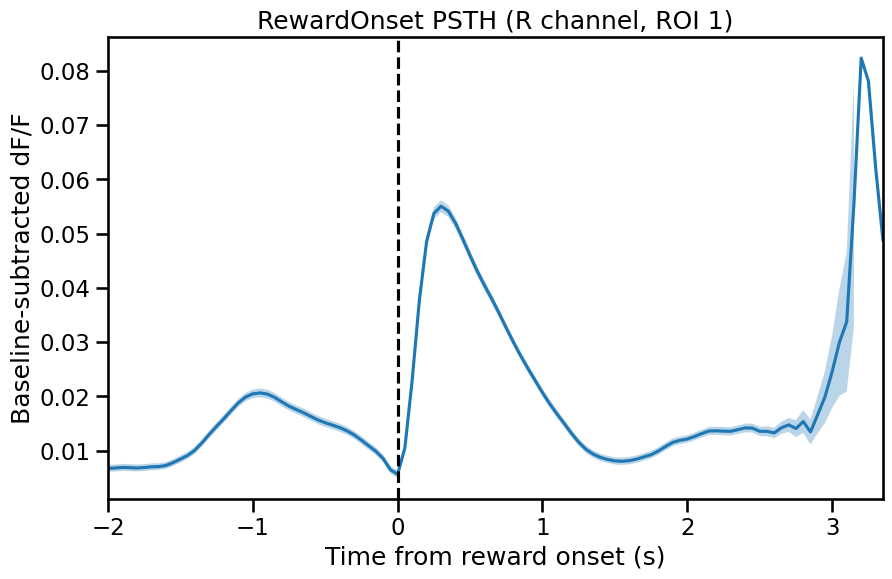

In [116]:
import matplotlib.pyplot as plt

# reward_psth should already exist from the previous steps
plt.figure(figsize=(10,6))
plt.plot(reward_psth["t_rel_reward"], reward_psth["mean"])
plt.fill_between(
    reward_psth["t_rel_reward"],
    reward_psth["mean"] - reward_psth["sem"],
    reward_psth["mean"] + reward_psth["sem"],
    alpha=0.3,
)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Time from reward onset (s)")
plt.ylabel("Baseline-subtracted dF/F")
plt.title("RewardOnset PSTH (R channel, ROI 1)")

plt.xlim(reward_psth["t_rel_reward"].min(), reward_psth["t_rel_reward"].max())

plt.show()

In [123]:
#Reward Ordinal attempt

# Keep only OdorSite choice epochs (events)
od_ev = epochs[
    (epochs["label"] == "OdorSite") &
    (epochs["is_choice"].astype(bool))
].copy()

# Define a patch identifier.
# Use what you have available; these are typical:
patch_id_cols = [c for c in ["mouse","session_id","patch_onset"] if c in od_ev.columns]
od_ev["patch_id"] = od_ev[patch_id_cols].astype(str).agg("|".join, axis=1)

# Reward ordinal within patch (only counts rewarded sites)
od_ev = od_ev.sort_values(["patch_id","epoch_time"])
od_ev["reward_ordinal"] = (
    od_ev.groupby("patch_id")["is_reward"]
    .transform(lambda s: s.astype(int).cumsum())
)

# Mark rewarded events only
od_reward = od_ev[od_ev["is_reward"].astype(bool)].copy()

# Optional: keep only ordinals up to N
MAX_ORD = 9
od_reward = od_reward[od_reward["reward_ordinal"].between(1, MAX_ORD)]
od_reward[["epoch_id","patch_id","reward_ordinal"]].head()


,epoch_id,patch_id,reward_ordinal
2,788731_2025-12-09_2,788731|2025-12-09|1380145.3696,1
6,788731_2025-12-09_6,788731|2025-12-09|1380145.3696,2
8,788731_2025-12-09_8,788731|2025-12-09|1380145.3696,3
10,788731_2025-12-09_10,788731|2025-12-09|1380145.3696,4
14,788731_2025-12-09_14,788731|2025-12-09|1380145.3696,5


In [124]:
CHANNEL = "R"   # "G" or "Ctrl"
ROI = 1
ALIGN = "OdorSite"     # or "InterSite"
BASELINE_WIN = (-2.0, 0.0)   # use (-2, 0) or (-2, -0.5), etc.

# Pull aligned rows for those rewarded epochs
p = aligned[
    (aligned["align_label"] == ALIGN) &
    (aligned["channel"] == CHANNEL) &
    (aligned["roi"] == ROI) &
    (aligned["epoch_id"].isin(od_reward["epoch_id"]))
].copy()

# Attach ordinal label
p = p.merge(od_reward[["epoch_id","reward_ordinal"]], on="epoch_id", how="left")

# Baseline per epoch
b0, b1 = BASELINE_WIN
pre = p[(p["t_rel"] >= b0) & (p["t_rel"] < b1)]
base = pre.groupby("epoch_id")["value"].mean().rename("baseline")

p = p.join(base, on="epoch_id").dropna(subset=["baseline"])
p["value_bs"] = p["value"] - p["baseline"]


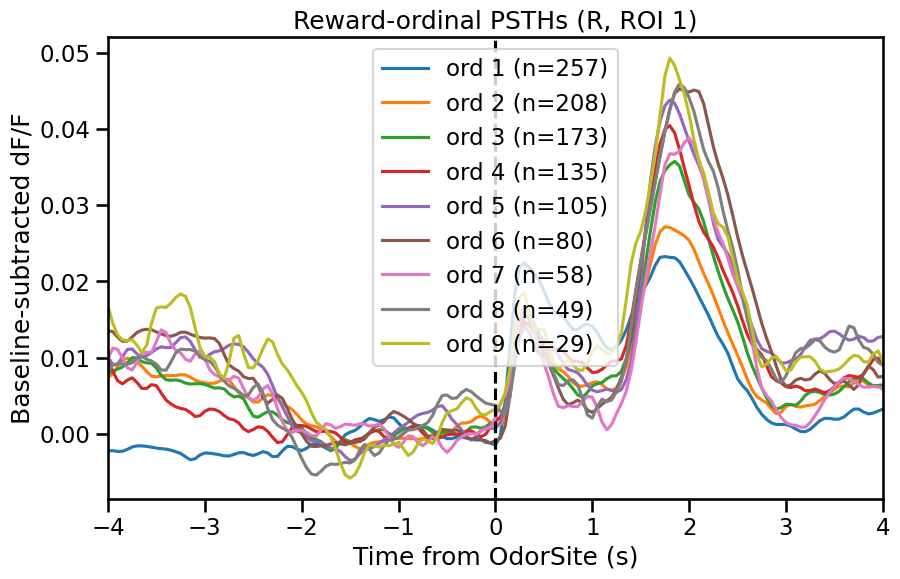

In [125]:
import matplotlib.pyplot as plt

def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return x.mean(), x.std(ddof=1)/np.sqrt(len(x)) if len(x) > 1 else (x.mean(), np.nan)

# aggregate: (ordinal, t_rel) -> mean, sem
grp = p.groupby(["reward_ordinal","t_rel"])["value_bs"]
stats = grp.agg(mean="mean", n="count", std="std").reset_index()
stats["sem"] = stats["std"] / np.sqrt(stats["n"])

plt.figure(figsize=(10,6))
for k in range(1, MAX_ORD+1):
    s = stats[stats["reward_ordinal"] == k]
    if s.empty: 
        continue
    plt.plot(s["t_rel"], s["mean"], label=f"ord {k} (n={int(s['n'].max())})")

plt.axvline(0, color="k", linestyle="--")
plt.xlim(p["t_rel"].min(), p["t_rel"].max())
plt.xlabel(f"Time from {ALIGN} (s)")
plt.ylabel("Baseline-subtracted dF/F")
plt.title(f"Reward-ordinal PSTHs ({CHANNEL}, ROI {ROI})")
plt.legend()
plt.show()


In [48]:
epochs.columns

Index(['epoch_time', 'label', 'start_position', 'length', 'friction',
       'patch_number', 'patch_label', 'odor_label', 'site_number', 'stop_time',
       'choice_cue_time', 'reward_onset_time', 'succesful_wait_time',
       'is_choice', 'is_reward', 'reward_amount', 'reward_probability',
       'reward_available', 'odor_sites', 'collected', 'depleted', 'last_visit',
       'last_site', 'cumulative_rewards', 'consecutive_rewards',
       'cumulative_failures', 'consecutive_failures',
       'after_choice_cumulative_rewards', 'duration_epoch', 'patch_onset',
       'time_since_entry', 'exit_epoch', 'skipped_count', 'mouse',
       'session_id', 'epoch_id', 'session', 'stage', 'session_path'],
      dtype='object')

In [50]:
##Conseuctive failures x Cumulative Rewards

state = epochs[[
    "epoch_id",
    "consecutive_failures",
    "cumulative_failures",
    "cumulative_rewards",
    "consecutive_rewards",
    "after_choice_cumulative_rewards",
    "patch_number",
    "mouse",
    "session_id",
    "label",
    "is_choice",
    "is_reward",
]].drop_duplicates("epoch_id")

aligned2 = aligned.merge(state, on="epoch_id", how="left", suffixes=("", "_epoch"))


In [51]:
##Conseuctive failures x Cumulative Rewards
baseline_lo, baseline_hi = -2.0, 0.0  # seconds

# baseline mask
is_base = (aligned2["t_rel"] >= baseline_lo) & (aligned2["t_rel"] < baseline_hi)

# mean baseline per (epoch_id, roi, channel)
baseline = (
    aligned2.loc[is_base]
    .groupby(["epoch_id", "roi", "channel"], sort=False)["value"]
    .mean()
    .rename("baseline")
    .reset_index()
)

aligned2 = aligned2.merge(baseline, on=["epoch_id", "roi", "channel"], how="left")
aligned2["value_bs"] = aligned2["value"] - aligned2["baseline"]


In [59]:
# Failures
aligned2["fail_bin"] = pd.cut(
    aligned2["consecutive_failures"],
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 100],
    labels=["0", "1", "2", "3", "4", "5","6","7","8"],
)

# Cumulative rewards
aligned2["rew_bin"] = pd.cut(
    aligned2["cumulative_rewards"],
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 100],
    labels=["0", "1", "2", "3", "4", "5","6","7","8"],
)


In [60]:
tmp = aligned2.query("align_label == 'OdorSite' and is_reward == 1").copy()
tmp = tmp.dropna(subset=["fail_bin", "rew_bin", "value_bs", "t_rel"])

mean_trace = (
    tmp.groupby(["channel", "roi", "fail_bin", "rew_bin", "t_rel"], sort=False)["value_bs"]
    .mean()
    .reset_index()
)

mean_trace_z = (
    tmp.groupby(["channel", "roi", "fail_bin", "rew_bin", "t_rel"], sort=False)["value_z"]
    .mean()
    .reset_index()
)

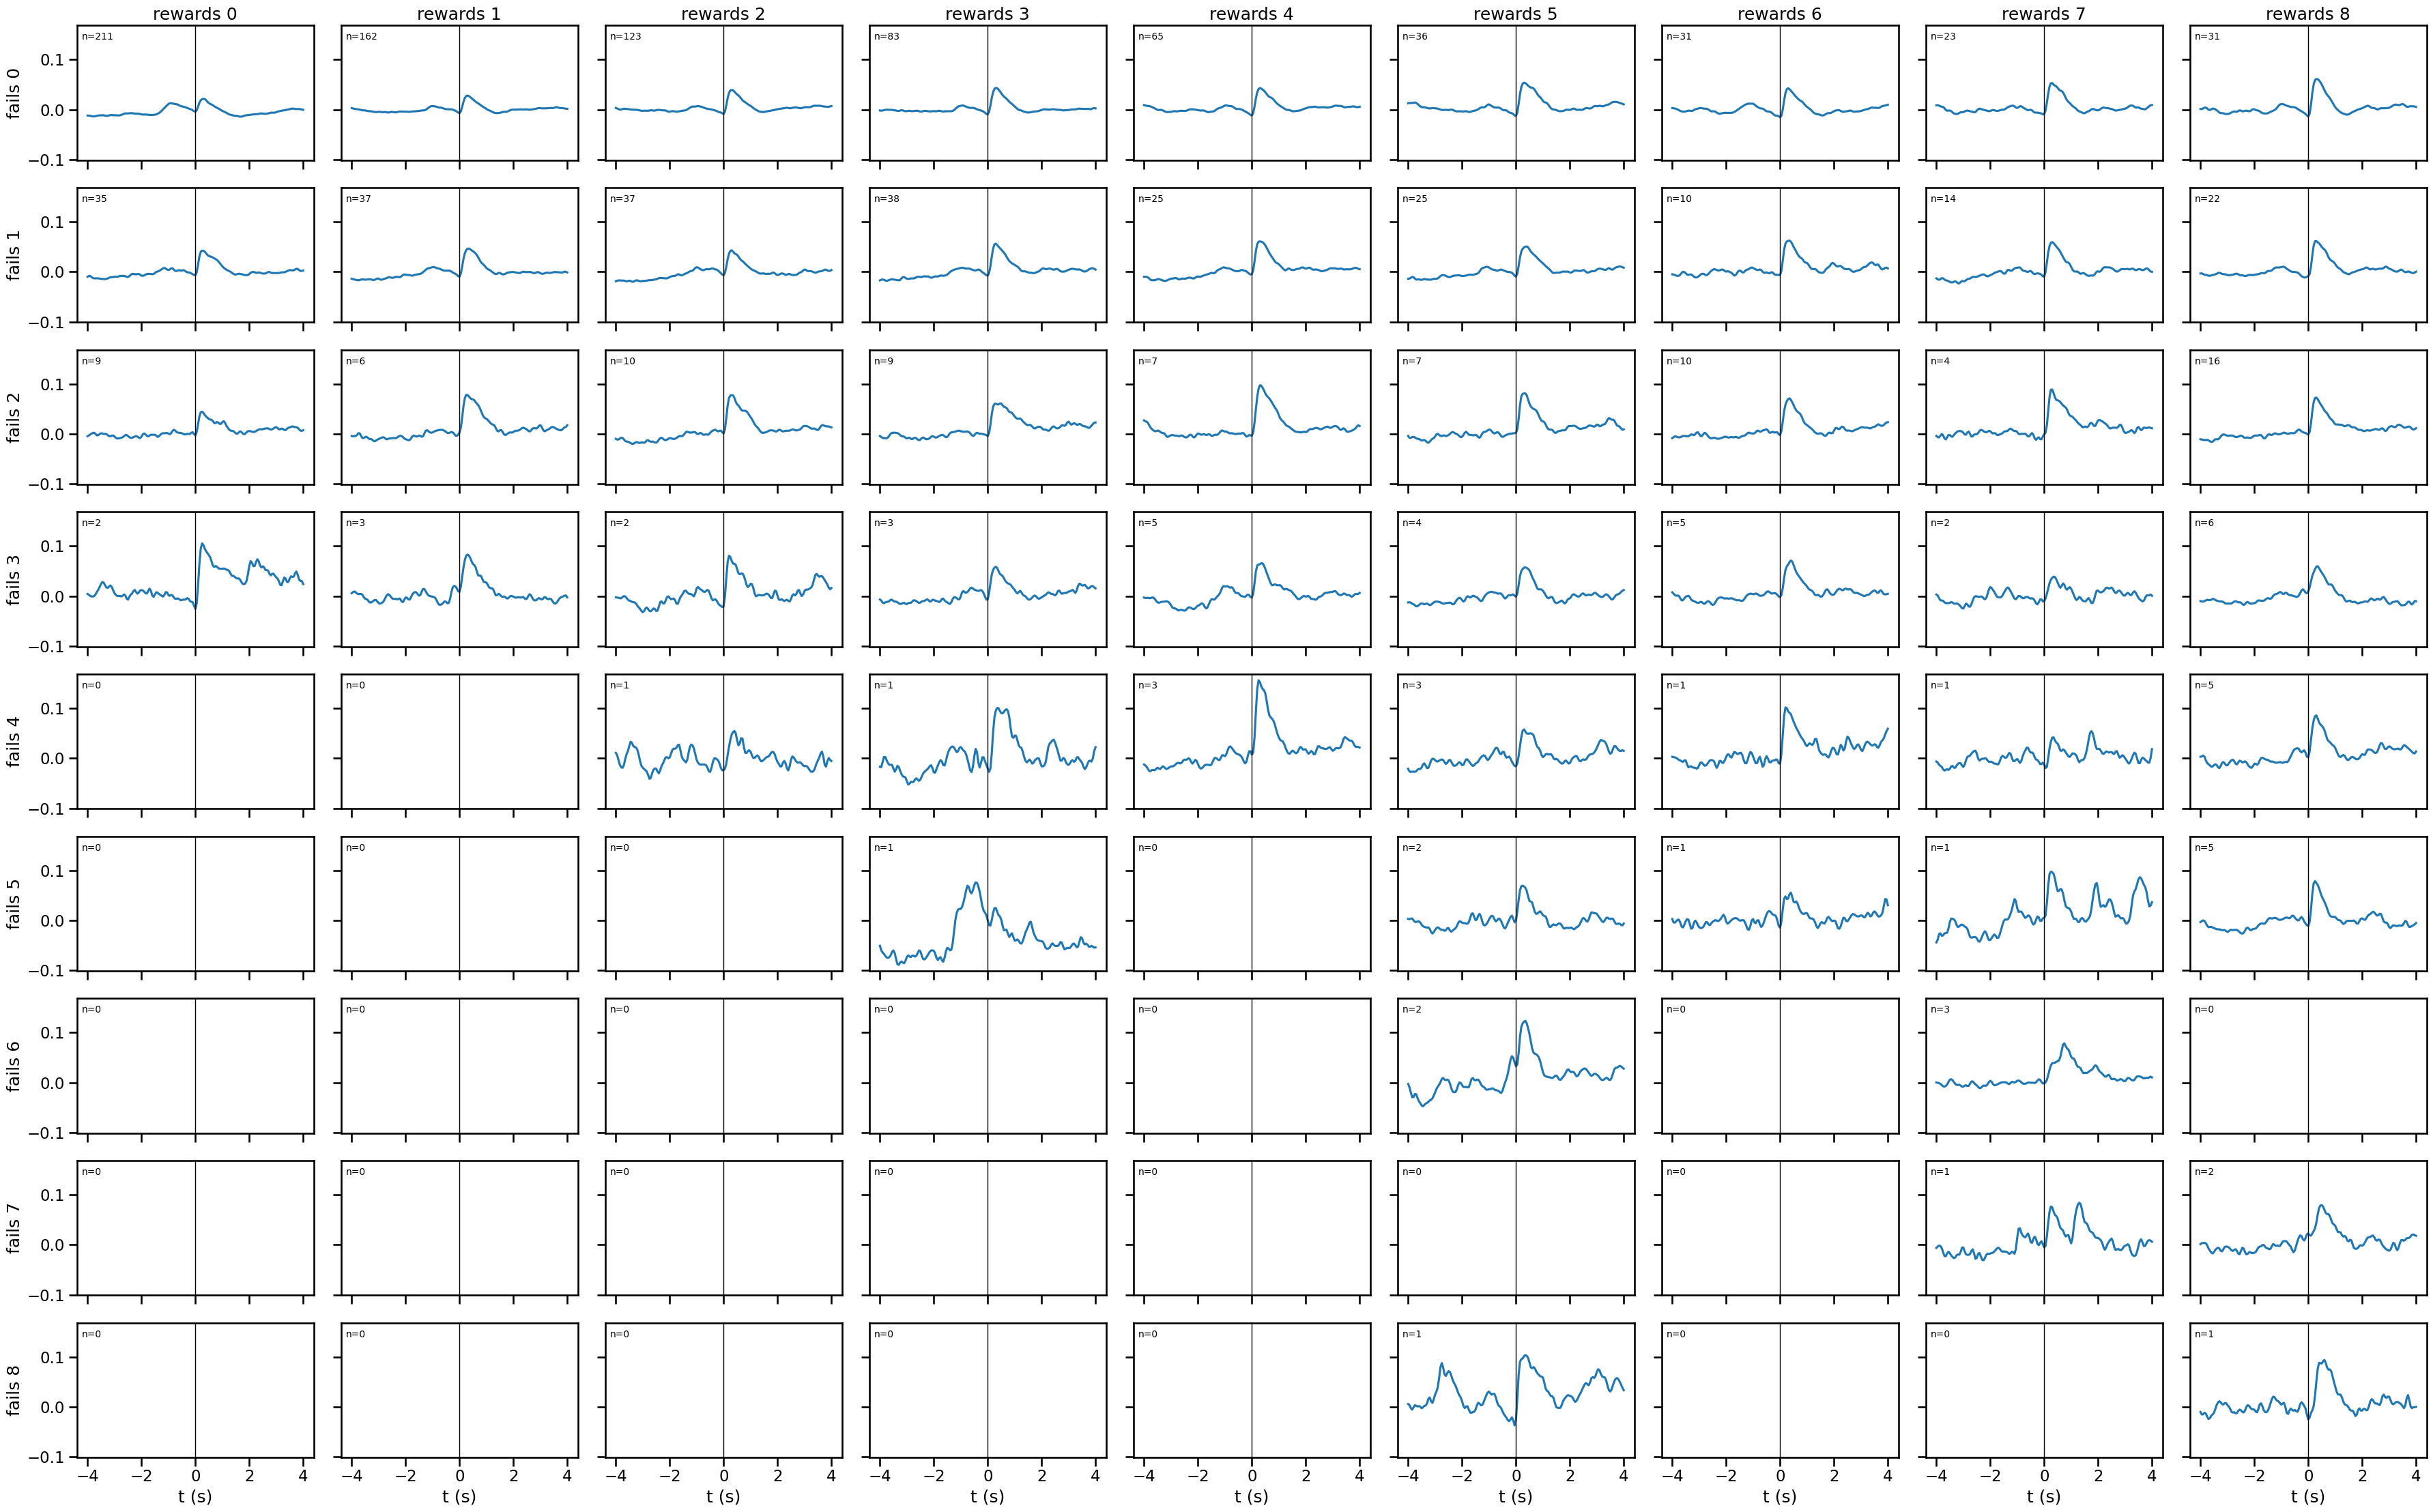

In [61]:
import matplotlib.pyplot as plt

channel = "R"
roi = 1

mt = mean_trace.query("channel == @channel and roi == @roi").copy()

fail_levels = list(mt["fail_bin"].cat.categories)
rew_levels  = list(mt["rew_bin"].cat.categories)

# --- compute N events per grid cell from the *event-level* table, not mean_trace ---
# Use the underlying aligned/per-epoch data you averaged to make mean_trace.
# Assuming you have `tmp` (or `aligned2`) with epoch_id, fail_bin, rew_bin, channel, roi.
counts = (
    tmp.query("channel == @channel and roi == @roi")
       .dropna(subset=["fail_bin","rew_bin"])
       .groupby(["fail_bin","rew_bin"])["epoch_id"]
       .nunique()
       .reindex(pd.MultiIndex.from_product([fail_levels, rew_levels], names=["fail_bin","rew_bin"]))
       .fillna(0)
       .astype(int)
)

fig, axes = plt.subplots(len(fail_levels), len(rew_levels),
                         figsize=(4*len(rew_levels), 2.5*len(fail_levels)),
                         sharex=True, sharey=True)

for i, f in enumerate(fail_levels):
    for j, r in enumerate(rew_levels):
        ax = axes[i, j]
        cell = mt[(mt["fail_bin"] == f) & (mt["rew_bin"] == r)]
        n = int(counts.loc[(f, r)])  # number of unique epoch_ids in this cell

        if not cell.empty:
            cell = cell.sort_values("t_rel")
            ax.plot(cell["t_rel"].to_numpy(), cell["value_bs"].to_numpy())

        ax.axvline(0, color="k", linewidth=1)

        # write N in axes coordinates (top-left)
        ax.text(
            0.02, 0.95, f"n={n}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10
        )

        if i == 0: ax.set_title(f"rewards {r}")
        if j == 0: ax.set_ylabel(f"fails {f}")
        if i == len(fail_levels)-1: ax.set_xlabel("t (s)")

plt.tight_layout()
plt.show()



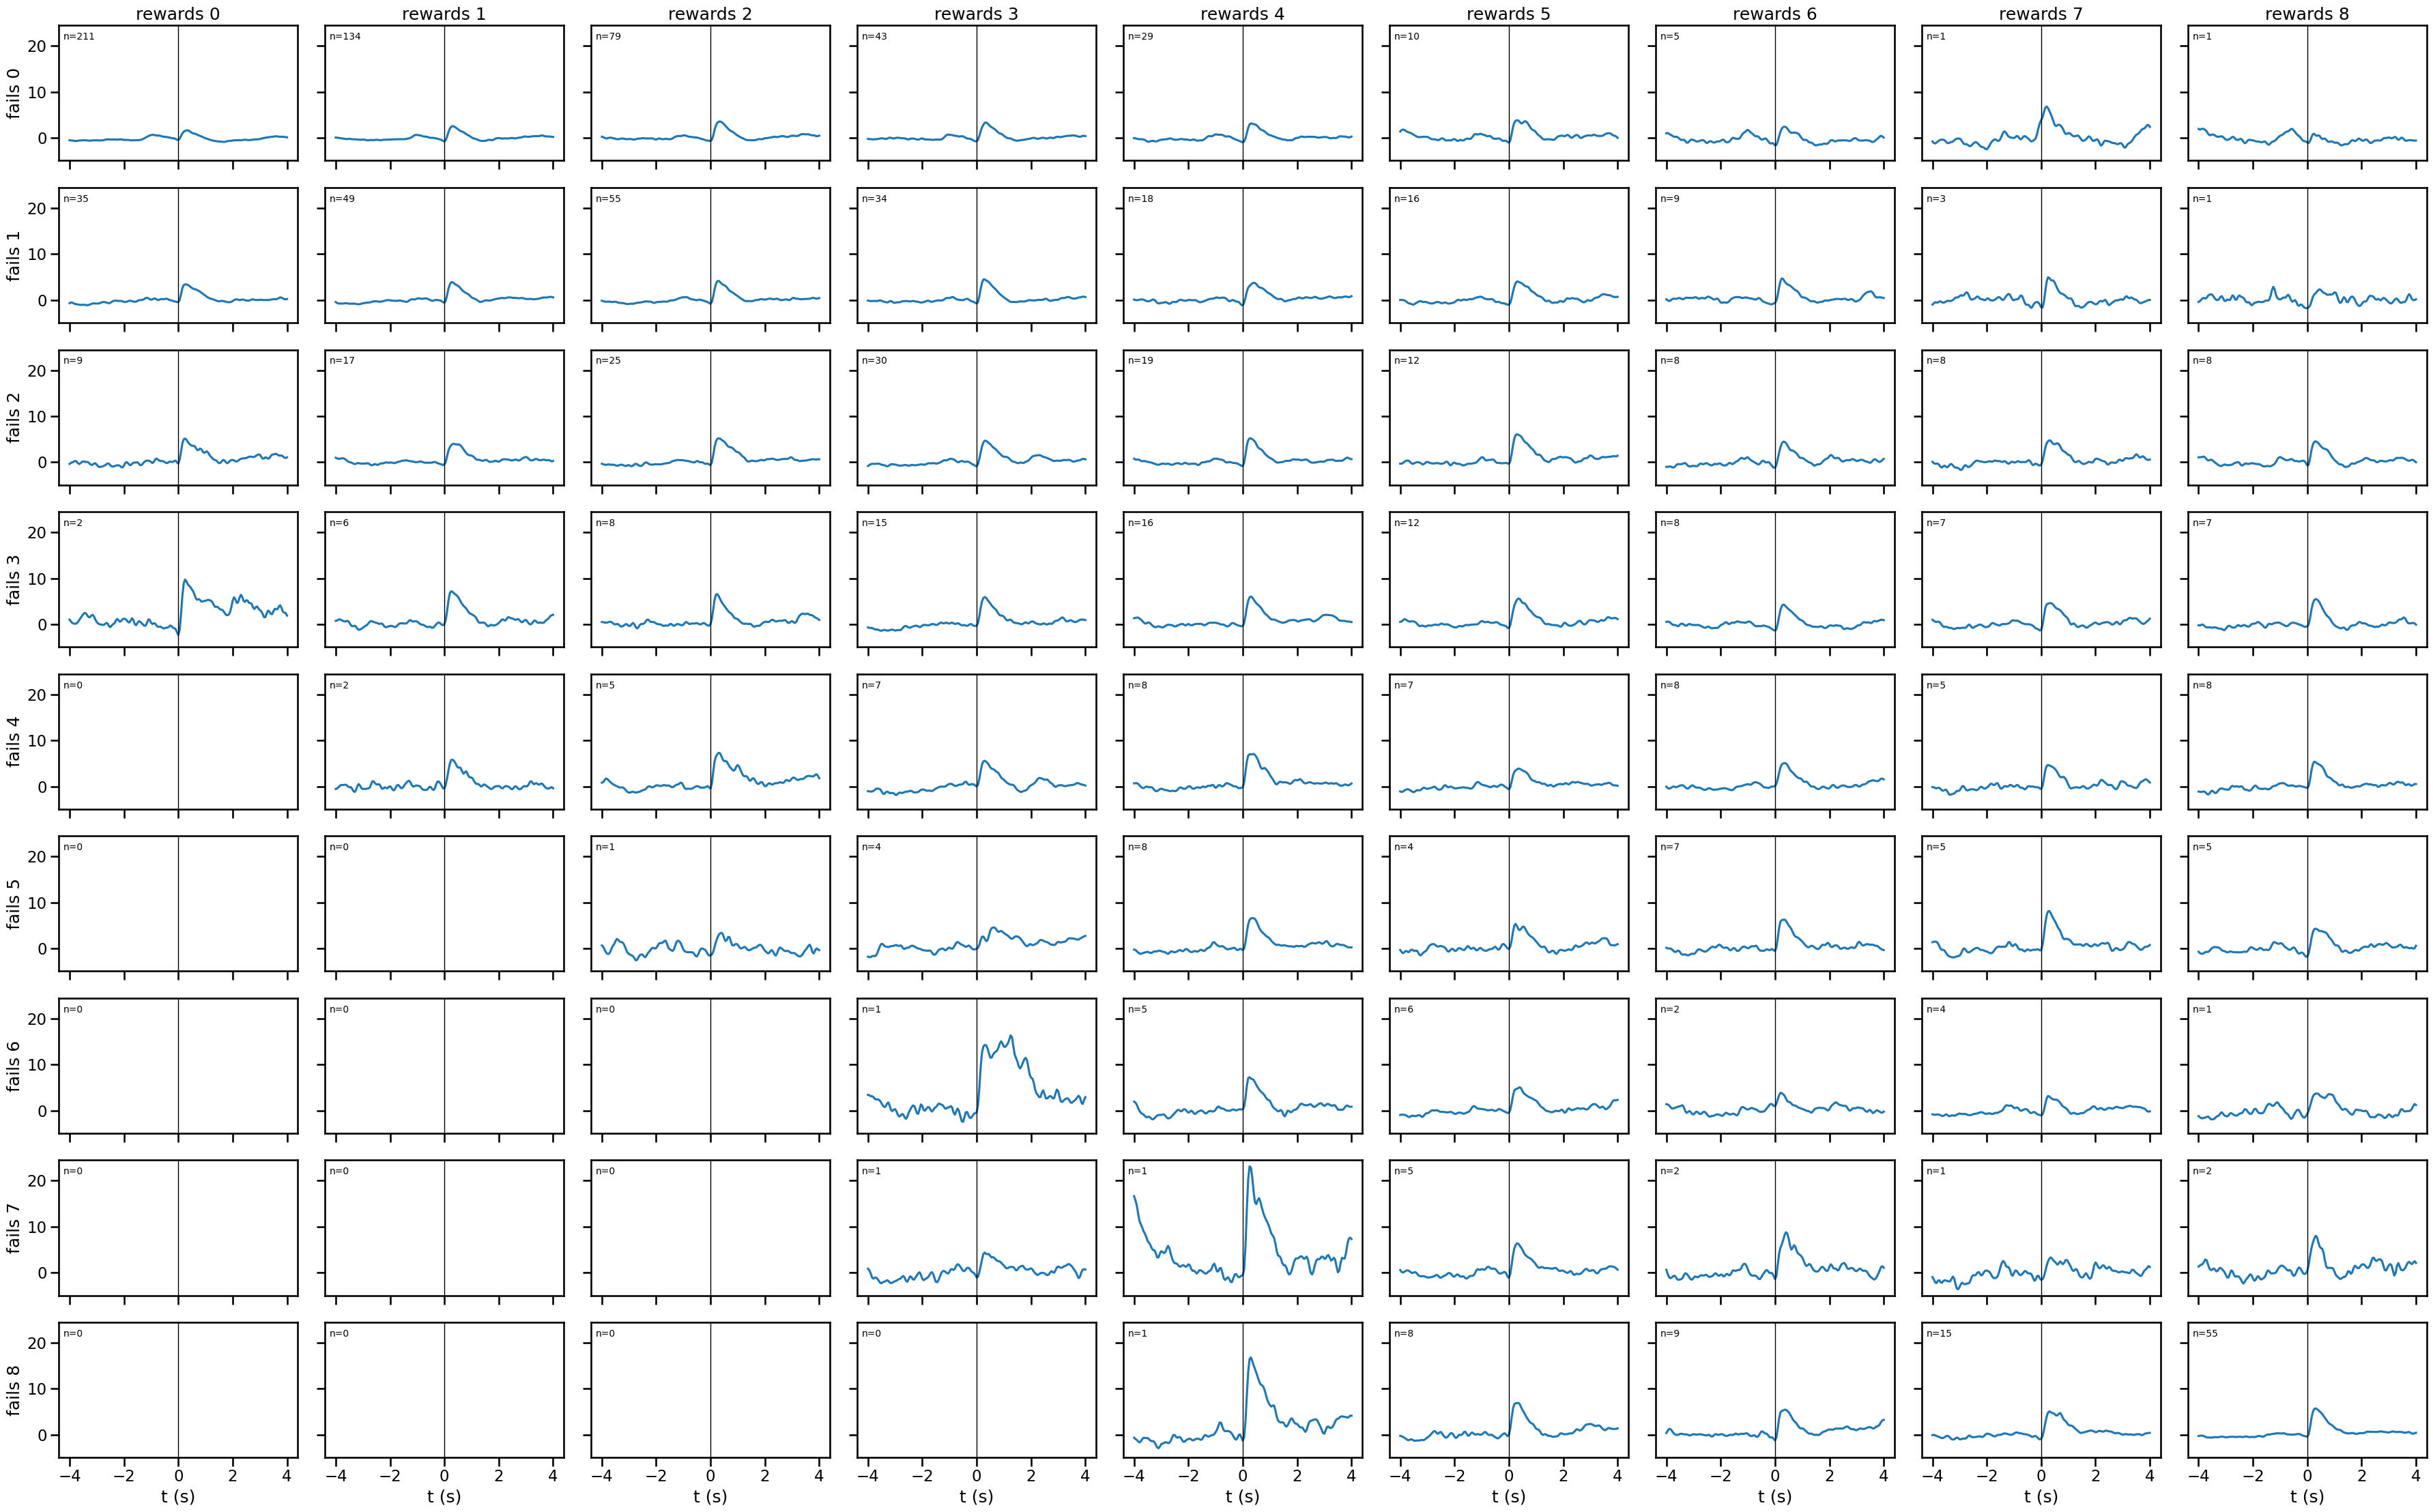

In [58]:
#Z-score, rewardONset version
import matplotlib.pyplot as plt

channel = "R"
roi = 1

mt = mean_trace_z.query("channel == @channel and roi == @roi").copy()

fail_levels = list(mt["fail_bin"].cat.categories)
rew_levels  = list(mt["rew_bin"].cat.categories)

# --- compute N events per grid cell from the *event-level* table, not mean_trace ---
# Use the underlying aligned/per-epoch data you averaged to make mean_trace.
# Assuming you have `tmp` (or `aligned2`) with epoch_id, fail_bin, rew_bin, channel, roi.
counts = (
    tmp.query("channel == @channel and roi == @roi")
       .dropna(subset=["fail_bin","rew_bin"])
       .groupby(["fail_bin","rew_bin"])["epoch_id"]
       .nunique()
       .reindex(pd.MultiIndex.from_product([fail_levels, rew_levels], names=["fail_bin","rew_bin"]))
       .fillna(0)
       .astype(int)
)

fig, axes = plt.subplots(len(fail_levels), len(rew_levels),
                         figsize=(4*len(rew_levels), 2.5*len(fail_levels)),
                         sharex=True, sharey=True)

for i, f in enumerate(fail_levels):
    for j, r in enumerate(rew_levels):
        ax = axes[i, j]
        cell = mt[(mt["fail_bin"] == f) & (mt["rew_bin"] == r)]
        n = int(counts.loc[(f, r)])  # number of unique epoch_ids in this cell

        if not cell.empty:
            cell = cell.sort_values("t_rel")
            ax.plot(cell["t_rel"].to_numpy(), cell["value_z"].to_numpy())

        ax.axvline(0, color="k", linewidth=1)

        # write N in axes coordinates (top-left)
        ax.text(
            0.02, 0.95, f"n={n}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10
        )

        if i == 0: ax.set_title(f"rewards {r}")
        if j == 0: ax.set_ylabel(f"fails {f}")
        if i == len(fail_levels)-1: ax.set_xlabel("t (s)")

plt.tight_layout()
plt.show()

In [41]:
aligned_long.columns
mean_trace.columns

Index(['channel', 'roi', 'fail_bin', 'rew_bin', 't_rel', 'value_bs'], dtype='object')